In [1]:
# https://medium.com/@keruchen/expectation-maximization-step-by-step-example-a9bb42add37d

In [2]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

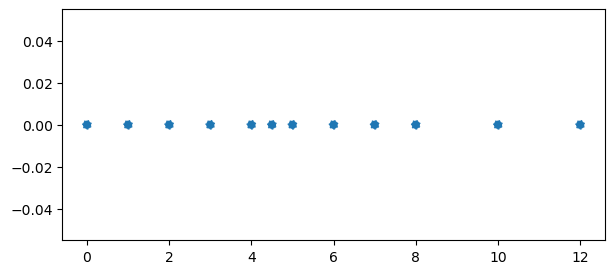

In [47]:
# initial some points along the line
samples = [0,1,3,4,5,6, 2,4.5,7,8,10,12]
# plot them
plt.rcParams["figure.figsize"] = [7, 3]
y_value = 0
y = np.zeros_like(samples) + y_value


plt.scatter(samples, y, ls='dotted')
plt.show()

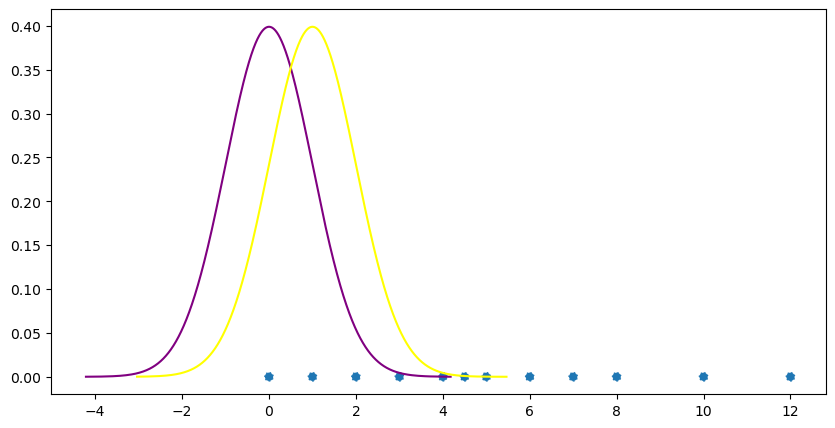

In [4]:
# first initial
mu1 = 0
sigma1 = 1
mu2 = 1
sigma2 = 1
# sample 100000 times from this two initial normal distribution 
samples_1 = np.random.normal(mu1, sigma1, 100000)
samples_2 = np.random.normal(mu2, sigma2, 100000)
# get pdf from the samples 
y_normal_1 = scipy.stats.norm(mu1, sigma1).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2, sigma2).pdf(np.sort(samples_2))
# plot
plt.rcParams["figure.figsize"] = [10, 5]
y_value = 0
y = np.zeros_like(samples) + y_value
plt.scatter(samples, y, ls='dotted')
plt.plot(np.sort(samples_1), y_normal_1, c='purple')
plt.plot(np.sort(samples_2), y_normal_2, c='yellow')
plt.show()

Now we can compute how likely is each points would be generated given these 2 distributions, the likelihood of x be sampled from N(mu, sigma) is:

$$y(X = x|\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$


The likelihood for x is the same as the y value from the normal distribution. This is because this function itself is called probability density function of x


Class 0:
    $$y*(X = x|0,1) = \frac{1}{\sqrt{2\pi}} * e^\frac{-x^2}{2}$$

Class 1:
    $$y*(X = x|1,1) = \frac{1}{\sqrt{2\pi}} * e^\frac{-(x-1)^2}{2}$$




<br>
<br>

The likelihood of X=0 given `class0` is 0.399, and the likelihood of X=0 given `class1` is 0.24:

In [5]:
# Likehood of class 0:
lh_c0 = 1/np.sqrt(2*3.14)*np.exp(-1/2 * 0**2)
f'{lh_c0:.3f}'

'0.399'

In [6]:
# Likehood of class 1:
lh_c1 = 1/np.sqrt(2*3.14)*np.exp(-1/2 * (0-1)**2)
f'{lh_c1:.3f}'

'0.242'

In [7]:
# For X = 12

# Likehood of class 0:
lh_c0 = 1/np.sqrt(2*3.14)*np.exp(-1/2 * 12**2)
lh_c0

2.146928005153545e-32

In [8]:
lh_c1 = 1/np.sqrt(2*3.14)*np.exp(-1/2 * (12-1)**2)
lh_c1

2.119356533333262e-27

The likelihoods for X=12 are very small for both class 0 and class 1 since it is so far from the center of both distributions, <br>
but we could still tell that X=12 has higher is more likely from class1 than class0.

In [9]:
# get likelihood for each x from gaussian_1 and gaussian_0
# get likelihood of x in gaussian_1
likelihood_x_gaussian_1 = [1/np.sqrt(2*3.14) * np.exp((-1/2)*(xi**2)) for xi in samples]
# get likelihood of x in gaussian_0
likelihood_x_gaussian_0 = [1/np.sqrt(2*3.14) * np.exp((-1/2)*((xi-1)**2)) for xi in samples]
# create a dataframe 
df_likelihood = pd.DataFrame([samples, likelihood_x_gaussian_1, likelihood_x_gaussian_0]).transpose()
df_likelihood.columns = ['samples', 'p(X=x|class0)', 'p(X=x|class1)']
df_likelihood

,samples,p(X=x|class0),p(X=x|class1)
0,0.0,3.990434e-01,2.420321e-01
1,1.0,2.420321e-01,3.990434e-01
2,3.0,4.432972e-03,5.400466e-02
3,4.0,1.338642e-04,4.432972e-03
4,5.0,1.487097e-06,1.338642e-04
5,6.0,6.077424e-09,1.487097e-06
6,2.0,5.400466e-02,2.420321e-01
7,4.5,1.598779e-05,8.729040e-04
8,7.0,9.137037e-12,6.077424e-09
9,8.0,5.053552e-15,9.137037e-12


The likelihood function for this GMM model can be calculated as

$$likelihood = l= \prod_{i=1}^{n} [ p(class_{0}) * p(x_{i}|class_{0}) + p(class_{1}) * p(x_{i}|class_{1})   ] $$ 

$$ll = ln(l) = \prod_{i=1}^{n} ln[ p(class_{0}) * p(x_{i}|class_{0}) + p(class_{1}) * p(x_{i}|class_{1})   ] $$ 

The log likelihood for the initial run is `log(0.5*0.399 + 0.5*0.24) + ... + log( (0.5*2.14e-32) + (0.5*0.1.22e-27)) = -195.17`

In [10]:
np.sum(np.log((0.5* df_likelihood.iloc[:,2]) + (0.5* df_likelihood.iloc[:,1])))

-195.17336231394884

This is the likelihood we want to maximize further on. This is also called maximize likelihood estimation.

Then we could compute the probability of `class0` or `class1` occur given those samples:



$$p(class_{0}|X) = \frac{p(X|class_{0}) * p(class_{0})} { p(class_{0}) * p(x_{i}|class_{0}) + p(class_{1}) * p(x_{i}|class_{1}) }$$

$$p(class_{1}|X) = \frac{p(X|class_{1}) * p(class_{1})} { p(class_{0}) * p(x_{i}|class_{0}) + p(class_{1}) * p(x_{i}|class_{1}) }$$



$p(class_{0})$ and $p(class_{1})$ are called `priors`. 

They are telling us how likely each of them got picked when we are generating a new sample. <br>
Since we have no preference in either picking `class0` or `class1` to generate x, the prior we set here is `0.5`.



Then $p(class_{0}|x_{i})$ and $p(class_{1}|x_{i})$ are called `posteriors`.


$$Posterior = (likelihood * prior)/Evidence $$

In [11]:
p_x0c0 = 0.399
p_x0c1 = 0.242

prior_c0 = 0.5
prior_c1 = 0.5

#Then

posterior_c0 = p_x0c0*prior_c0/(p_x0c0*prior_c0 + p_x0c1*prior_c1)
posterior_c1 = p_x0c1*prior_c1/(p_x0c0*prior_c0 + p_x0c1*prior_c1)

posterior_c0, posterior_c1, posterior_c0 + posterior_c1

(0.6224648985959439, 0.37753510140405616, 1.0)

Here, we can say that the responsibility of `class0` for x=0 is `0.622` and, <br>
the responsibility of `class1` for x=0 is `0.377`.

The responsibility adds up to 1, since we only have 2 groups (possibilities): `class0` and `class1`.

In [12]:
# get likelihood of class0 and class1 occurs given samples
# define prior
prior_class_0 = 0.5
prior_class_1 = 0.5
# get likelihood of gaussian_1 occurs based on x1
df_likelihood['p(class0|x)'] = df_likelihood.apply(lambda row: 
                                                       row["p(X=x|class0)"] * 0.5/(row["p(X=x|class1)"]*0.5+row["p(X=x|class0)"]*0.5),axis =1)
# get likelihood of gaussian_0 occurs based on x1
df_likelihood['p(class1|x)'] = df_likelihood.apply(lambda row: 
                                                       row['p(X=x|class1)'] * 0.5/(row['p(X=x|class1)']*0.5+row['p(X=x|class0)']*0.5), axis=1)

df_likelihood

,samples,p(X=x|class0),p(X=x|class1),p(class0|x),p(class1|x)
0,0.0,3.990434e-01,2.420321e-01,0.622459,0.377541
1,1.0,2.420321e-01,3.990434e-01,0.377541,0.622459
2,3.0,4.432972e-03,5.400466e-02,0.075858,0.924142
3,4.0,1.338642e-04,4.432972e-03,0.029312,0.970688
4,5.0,1.487097e-06,1.338642e-04,0.010987,0.989013
5,6.0,6.077424e-09,1.487097e-06,0.004070,0.995930
6,2.0,5.400466e-02,2.420321e-01,0.182426,0.817574
7,4.5,1.598779e-05,8.729040e-04,0.017986,0.982014
8,7.0,9.137037e-12,6.077424e-09,0.001501,0.998499
9,8.0,5.053552e-15,9.137037e-12,0.000553,0.999447


Only for `x=0` it is more likely to be in `class0` and all the other points are more likely to be `class1`.

That is because we shift `class1` to the right by unit of 1 `(mu=1)`.

So we can see that by shifting the mean of the distribution, we would move the distribution closer to the points where the cluster is taking greater responsibilities.

To maximize the likelihood, we need to update mu to the mean of samples from the distribution, and sigma to the mean of the variance of samples from the distribution.


Since we aren’t sure which samples are from class0 or class1, we could estimate the mean using expectation.

For a discrete variable X, the expectation of X is:


$$ E(X) = \sum_{i=1}^{n} (X=x_{i}) * p(X=x_{i}) $$

Assuming that

$$ \sum_{i=1}^{n} p(X=x_{i}) = 1 $$



In [ ]:
# For class0, the discrete variable X is our samples here:

X=[0, 1, 3, 4, 5, 6, 7, 2, 2.5, 4.5, 8, 10, 12]

In [20]:
# The probability of class0 given X is:
p_xi_class0 = df_likelihood.iloc[:,3].tolist()
[np.round(i,3) for i in p_xi_class0[:5]], np.sum(p_xi_class0)

([0.622, 0.378, 0.076, 0.029, 0.011], 1.3227781619996892)

In [24]:
# Let’s standardize p(X=xi) to make sure we meet the assumption:

p_xi_class0_std = p_xi_class0/np.sum(p_xi_class0)
p_xi_class0_std[:3],np.sum(p_xi_class0_std)

(array([0.47056971, 0.28541495, 0.05734762]), 1.0)

In [23]:
df_likelihood['p(class0|x)_standardized'] = df_likelihood['p(class0|x)'] / sum(df_likelihood['p(class0|x)'])
df_likelihood['p(class1|x)_standardized'] = df_likelihood['p(class1|x)'] / sum(df_likelihood['p(class1|x)'])
df_likelihood

,samples,p(X=x|class0),p(X=x|class1),p(class0|x),p(class1|x),p(class0|x)_standardized,p(class1|x)_standardized
0,0.0,3.990434e-01,2.420321e-01,0.622459,0.377541,0.470570,0.035359
1,1.0,2.420321e-01,3.990434e-01,0.377541,0.622459,0.285415,0.058298
2,3.0,4.432972e-03,5.400466e-02,0.075858,0.924142,0.057348,0.086553
3,4.0,1.338642e-04,4.432972e-03,0.029312,0.970688,0.022160,0.090912
4,5.0,1.487097e-06,1.338642e-04,0.010987,0.989013,0.008306,0.092628
5,6.0,6.077424e-09,1.487097e-06,0.004070,0.995930,0.003077,0.093276
6,2.0,5.400466e-02,2.420321e-01,0.182426,0.817574,0.137911,0.076572
7,4.5,1.598779e-05,8.729040e-04,0.017986,0.982014,0.013597,0.091973
8,7.0,9.137037e-12,6.077424e-09,0.001501,0.998499,0.001135,0.093517
9,8.0,5.053552e-15,9.137037e-12,0.000553,0.999447,0.000418,0.093606


In [43]:
# Now let’s update mu1, sigma1, mu2, sigma2

''' 
mu1_new = E(mu1) 
        = sum of (xi * p(class0|X=xi))
        = 0 * 0.43 + 1 * 0.26 + 3 * 0.05 + ....+ 12 * 0.000007
        = 1.08
variance1_new = E(variance) 
           = sum of ((xi - mu1_new)^2 * p(class0| X=xi))
           = (0-1.08)^2*0.47+(1-1.08)^2*0.28+..+(12-1.08)^2*0.000008
           = 1.54
sigma1_new = square_root(variance1_new/N) 
           = square_root(1.54 / 12)
           = 0.34
mu2_new = E(mu2) 
        = sum of (xi * p(Gaussian_0|X=xi)) 
        = 0 * 0.035 + 1 * 0.058 + ... + 12*0.0936 
        = 5.48
variance2_new = E(variance) 
           = sum of ((xi - mu2_new)^2 * p(class1| X=xi))
           = (0-5.49)^2*0.033+(1-5.49)^2*0.053...+(12-5.49)^2*0.086
           = 10.59
sigma1_new = square_root(variance2_new/N) 
           = square_root(10.59 / 12)
           = 0.90

'''

mu1_new = np.sum(df_likelihood['samples'] * df_likelihood['p(class0|x)_standardized'])
var1_new = np.sum((df_likelihood['samples'] - mu1_new)**2 * df_likelihood['p(class0|x)_standardized'] )
sigma1_new = np.sqrt(var1_new/len(df_likelihood))

mu2_new = np.sum(df_likelihood['samples'] * df_likelihood['p(class1|x)_standardized'])
var2_new = np.sum((df_likelihood['samples'] - mu2_new)**2 * df_likelihood['p(class1|x)_standardized'] )
sigma2_new = np.sqrt(var2_new/len(df_likelihood))


(mu1_new, var1_new, sigma1_new), (mu2_new, var2_new, sigma2_new)

((0.9550423699975553, 1.4785144696576509, 0.35101216380367445),
 (5.735264447839885, 10.66561373082391, 0.9427625068039808))

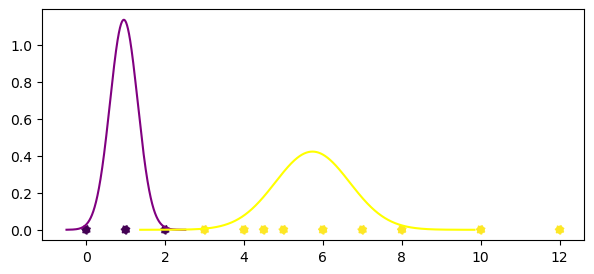

In [ ]:
# generate class label if we need a hard assignment
p0 = [scipy.stats.norm(mu1_new,sigma1_new).pdf(x) for x in samples]
p1 = [scipy.stats.norm(mu2_new,sigma2_new).pdf(x) for x in samples]

class_pred= []
for x, y in zip(p0, p1):
    if x < y: 
        class_pred_i = 1
    else:
        class_pred_i = 0
    class_pred.append(class_pred_i)
# sample 100000 times from this two updated normal distribution from initial
samples_1 = np.random.normal(mu1_new, sigma1_new, 100000)
samples_2 = np.random.normal(mu2_new, sigma2_new, 100000)
# get pdf from the samples 
y_normal_1 = scipy.stats.norm(mu1_new, sigma1_new).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2_new, sigma2_new).pdf(np.sort(samples_2))


# plot 
plt.rcParams["figure.figsize"] = [7, 3]
y_value = 0
y = np.zeros_like(samples) + y_value
plt.scatter(samples, y, ls='dotted', c=class_pred)
plt.plot(np.sort(samples_1), y_normal_1, c='purple')
plt.plot(np.sort(samples_2), y_normal_2, c='yellow')
plt.show()

In [48]:
# update the prior
prior_class_0 = sum(df_likelihood['p(class0|x)'])/ 13
print(prior_class_0)
prior_class_1 = 1 - prior_class_0
print(prior_class_1)

0.10175216630766837
0.8982478336923316


Now we have new parameters for the prior, mean (mu), and variance (sigma) for both classes.


We then going to the iteration again and again:

1. "E step": Calculate `p(xi|class0)~N(mu1, sigma1)` and `p(xi|class1)~N(mu2, sigma2)`, `p(class0|xi)` and `p(class1|xi)` and the likelihood function.
2. "M step": Update mu1, sigma1, mu2, sigma2, prior(class0), prior(class1) which try to maximize the likelihood in E step.

Until:


1. Maximum iteration reached
2. The likelihood is converged — the change of likelihood < threshold


This is the EM algorithm:

> “The EM iteration alternates between performing an expectation (E) step, which creates a function for the expectation of the log-likelihood evaluated using the current estimate for the parameters, <br> 
    and a maximization (M) step, which computes parameters maximizing the expected log-likelihood found on the E step. <br>
    These parameter-estimates are then used to determine the distribution of the latent variables in the next E step.” — Wikipedia



The __latent variables__ in this case is the parameters of two normal distributions — mu1, sigma1, mu2, sigma2.<br>
Those variables are hidden and unknown, that’s why they are called ‘latent variables’.

The E step in this exercise is the step we generate likelihood of p(xi|classj).<br>
The M steps here is the step we update the parameters in a way to maximize the likelihood in E step.



In [28]:
# initial df 

# df
label = [1,1,1,1,1,1, 0,0,0,0,0,0,0]
samples = [0,1,3,4,5,6,7, 2,2.5,4.5,8,10,12]
df = pd.DataFrame([samples, label]).transpose()
df.columns = ['samples', 'label']
# ---------------------------------------------------------
# define function 
def expectation_maximization(df,mu1, sigma1, mu2, sigma2, prior_class_1, prior_class_0,max_iteration):
    
    likelihoods = []
    i = 0
    while i <= max_iteration:
        # E step
        # get likelihood of x in class0
        df['p(X=x|class0)'] = [scipy.stats.norm(mu1, sigma1).pdf(x) for x in df.samples]
        # get likelihood of x in class1
        df['p(X=x|class1)'] = [scipy.stats.norm(mu2, sigma2).pdf(x) for x in df.samples]
        
        # get likelihood that need to be maximized 
        likelihood = sum([np.log(x) for x in (prior_class_1*df['p(X=x|class0)']+prior_class_0*df['p(X=x|class1)'])])
        likelihoods.append(likelihood)
        ## get likelihood of class0 given x
        df['p(class0|x)'] = df.apply(lambda row: 
                                         row["p(X=x|class0)"] * prior_class_1/(row["p(X=x|class0)"]*prior_class_1+row["p(X=x|class1)"]*prior_class_1),
                                         axis =1
                                        )
        ## get likelihood of class1 occurs given x
        df['p(class1|x)'] = df.apply(lambda row: 
                                         row['p(X=x|class1)'] * prior_class_0/(row['p(X=x|class0)']*prior_class_0+row['p(X=x|class1)']*prior_class_0),
                                         axis=1
                                        )
        # standardize the likelihood 
        df['p(class0|x)_standardized'] = df['p(class0|x)'] / sum(df['p(class0|x)'])
        df['p(class1|x)_standardized'] = df['p(class1|x)'] / sum(df['p(class1|x)'])
        # M step:
        ## update the parameters by taking expectation 
        mu1 = sum(df['samples'] * df['p(class0|x)_standardized'])
        variance1_new = sum((df['samples']-mu1)**2 * df['p(class0|x)_standardized'])
        sigma1 = np.sqrt(variance1_new/df.shape[0])
        mu2 = sum(df['samples'] * df['p(class1|x)_standardized'])
        variance2_new = sum((df['samples']-mu2)**2 * df['p(class1|x)_standardized'])
        sigma2 = np.sqrt(variance2_new/df.shape[0])
        # Update prior
        prior_class_1 = sum(df['p(class0|x)'])/ df.shape[0]
        prior_class_0 = sum(df['p(class1|x)'])/ df.shape[0]
        # assign samples into class after updating parameters
        p0 = [scipy.stats.norm(mu1,sigma2).pdf(x) for x in df['samples']]
        p1 = [scipy.stats.norm(mu2,sigma2).pdf(x) for x in df['samples']]
        # predict class for plotting
        class_pred= []
        for x, y in zip(p0, p1):
            if x < y: 
                class_pred_i = 1
            else:
                class_pred_i = 0
            class_pred.append(class_pred_i)
            
        df['class_pred'] = class_pred
        
        i += 1
    
    return mu1, sigma1, mu2, sigma2, likelihoods, df
# ---------------------------------------------------------
# run this function for 10 times 
mu1, sigma1, mu2, sigma2, likelihood, df_final = expectation_maximization(df=df, mu1=0, sigma1=1, mu2=1, sigma2=1, prior_class_1=0.5, prior_class_0=0.5, max_iteration = 10)
mu1, sigma1, mu2, sigma2,

(0.9975669750052162, 0.2263186239265926, 6.196935594612617, 0.8093996532557958)

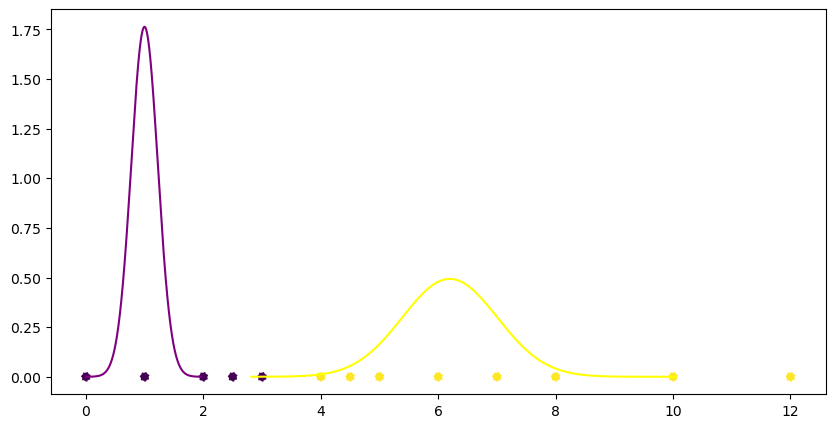

In [5]:
# sample 100000 times from this two updated normal distribution from initial
samples_1 = np.random.normal(mu1, sigma1, 100000)
samples_2 = np.random.normal(mu2, sigma2, 100000)
# get pdf from the samples 
y_normal_1 = scipy.stats.norm(mu1, sigma1).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2, sigma2).pdf(np.sort(samples_2))
# plot 
plt.rcParams["figure.figsize"] = [10, 5]
y_value = 0
y = np.zeros_like(samples) + y_value
plt.scatter(samples, y, ls='dotted', c=df_final['class_pred'])
plt.plot(np.sort(samples_1), y_normal_1, c='purple')
plt.plot(np.sort(samples_2), y_normal_2, c='yellow')

In [29]:
mu1, sigma1, mu2, sigma2

(0.9975669750052162, 0.2263186239265926, 6.196935594612617, 0.8093996532557958)

After 10 iterations the parameters for the two classes are:

$Class0 ~ N(0.99, 0.22)$

and

$Class1 ~ N(6.19, 0.81)$

Suppose we get a new sample `x=0.5`, we could calculate the likelihood of x=5 given `class0` and `class1`:

$p(x=5|class0) = \frac{1}{\sqrt{2\pi*0.22}} * e^\frac{-(0.5-0.99)^2}{2*0.22}$

$p(x=5|class1) = \frac{1}{\sqrt{2\pi*0.81}} * e^\frac{-(0.5-6.19)^2}{2*0.81}$


In [30]:
pxClass0 = scipy.stats.norm(mu1, sigma1).pdf(5),
pxClass1 = scipy.stats.norm(mu2, sigma2).pdf(5)

In [31]:
pxClass0  / (pxClass0+pxClass1), pxClass1  / (pxClass0+pxClass1)

(array([1.29988931e-67]), array([1.]))

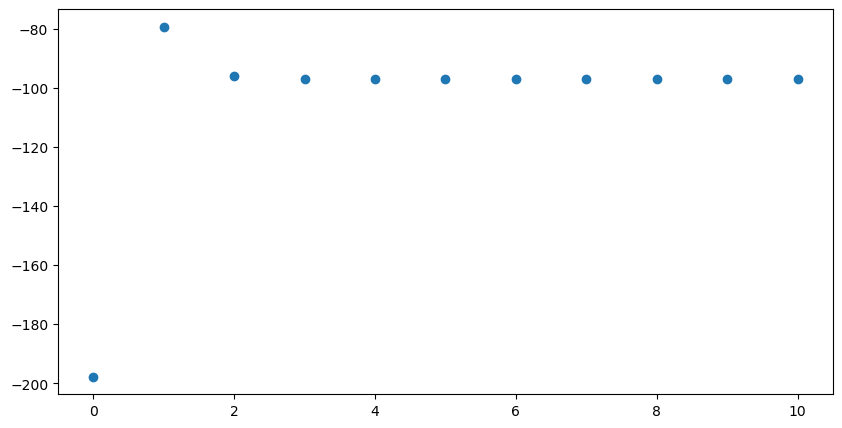

In [32]:
plt.scatter(range(len(likelihood)), likelihood)